<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%202/1_Introduction_to_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Convolutional Neural Networks with PyTorch

## Overview
In this tutorial we build, train, and evaluate a **Convolutional Neural Network (CNN)** using PyTorch on the classic **MNIST handwritten-digit dataset**. By the end you will understand:

| Step | What you will learn |
|------|---------------------|
| 1 | Loading and exploring image data |
| 2 | Representing images as PyTorch tensors |
| 3 | The building blocks of a CNN (convolution, pooling, activation) |
| 4 | Defining a CNN with `torch.nn.Module` |
| 5 | Training and evaluating the model |
| 6 | Moving computation to GPU |

**Prerequisites:** Basic Python, familiarity with NumPy arrays, and the previous PyTorch sessions.

**Key references:**
- [PyTorch `nn.Module` tutorial](https://pytorch.org/tutorials/beginner/nn_tutorial.html)
- [PyTorch MNIST tutorial on Kaggle](https://nextjournal.com/gkoehler/pytorch-mnist)

---
## Step 1 — Import Libraries

We import the following libraries:

| Library | Purpose |
|---------|----------|
| `numpy` | Numerical array operations |
| `matplotlib` | Plotting and visualisation |
| `torch` | Core PyTorch tensor operations |
| `torch.nn` | Neural network building blocks (layers, loss functions) |
| `torch.nn.functional` | Stateless functions such as `relu`, `max_pool2d`, `cross_entropy` |
| `torch.optim` | Optimisation algorithms (SGD, Adam, …) |
| `torchvision` | Computer-vision utilities and pre-built datasets |

> **Tip:** `torch.nn` contains classes that *hold learnable parameters* (weights), while `torch.nn.functional` contains the *plain mathematical operations* that do not store state.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import torchvision
from torch import nn
from torch import optim

---
## Step 2 — Load the MNIST Dataset

### About MNIST
MNIST is a dataset of **70,000 greyscale images** of handwritten digits (0–9), each 28×28 pixels.
It is split into:
- **50,000 training samples** — used to fit the model
- **10,000 validation samples** — used to evaluate how well the model generalises

It is often called the *"Hello, World!"* of machine learning because it is small enough to train quickly yet realistic enough to be meaningful.

### File format
The data is stored as a **gzip-compressed pickle file** (`mnist.pkl.gz`).  
`gzip.open` decompresses it and `pickle.load` deserialises the Python objects inside — giving us three tuples:
```
(x_train, y_train)   # 50 000 training images + labels
(x_valid, y_valid)   # 10 000 validation images + labels
_                    # test set (not used here)
```
Each image is currently stored as a **flat 784-element vector** (28 × 28 = 784). We will reshape it later.

In [ ]:
from pathlib import Path
import requests
import pickle
import gzip

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"
FILENAME = "mnist.pkl.gz"

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

C:\Users\babu_m\AppData\Local\Temp\ipykernel_54504\2070601830.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")


---
## Step 3 — Explore the Data

Before building any model it is good practice to **visualise the raw data**.  
We call `reshape((28, 28))` to convert the flat 784-vector back into a 2-D image matrix so that `imshow` can render it.  
The `cmap="gray"` argument tells Matplotlib to use a greyscale colour map.

> **What to look for:** Notice the pixel values range from 0 (black) to 1 (white). The label tells us which digit the image represents.

true label:  5


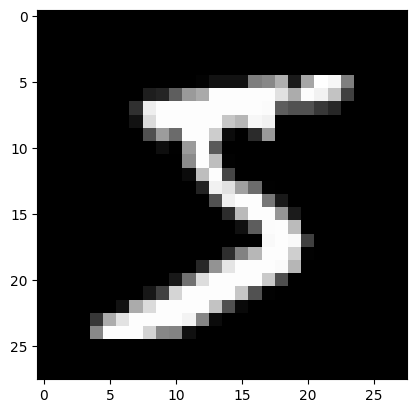

In [ ]:
plt.imshow(x_train[0].reshape((28, 28)), cmap="gray")
print("true label: ", y_train[0].item())

---
## Step 4 — Convert Data to PyTorch Tensors

PyTorch operates on **tensors** (its equivalent of NumPy arrays), not plain NumPy arrays.  
We use `map(torch.tensor, ...)` to convert all four arrays in one line — a neat Python idiom.

After conversion we inspect:
- **`x_train.shape`** — should be `(50000, 784)`, confirming 50,000 flat images
- **`y_train.min()` and `y_train.max()`** — should be `0` and `9`, confirming the 10 digit classes

We also record `n` (number of training samples) and `c` (number of features per sample) which we will use when setting up the training loop.

In [ ]:
x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid))

n, c = x_train.shape

print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


---
## Step 5 — Understanding Convolutional Neural Networks

### Why CNNs for images?
A plain fully-connected network treats every pixel as an independent input feature. It throws away all **spatial structure** — the fact that neighbouring pixels tend to belong to the same edge or shape. This means it needs a huge number of parameters and struggles to generalise.

CNNs solve this by applying **shared, learnable filters** that slide across the image, looking for local patterns (edges, curves, corners). Key properties:

| Property | Benefit |
|----------|---------|
| **Weight sharing** | The same filter is applied everywhere — far fewer parameters |
| **Translation invariance** | A cat in the top-left and a cat in the bottom-right both activate the same filter |
| **Hierarchical features** | Early layers detect edges; deeper layers detect objects |

### The Convolution Operation
A filter (also called a *kernel*) is a small matrix (e.g. 5×5) of learnable weights. The dot product between the filter and each overlapping patch of the input produces a single output value. Sliding the filter across the entire image produces a 2-D **feature map**.

$$\text{output}[i,j] = \sum_{m}\sum_{n} \text{input}[i+m, j+n] \cdot \text{kernel}[m, n]$$

### Max Pooling
After convolution we apply **max pooling** to down-sample the feature maps. A 2×2 max pool takes the maximum value from each 2×2 non-overlapping patch, halving the spatial dimensions and making the representation more compact and robust to small shifts.

### Working out output dimensions
For a convolution with no padding:
$$\text{output size} = \left\lfloor \frac{\text{input size} - \text{kernel size}}{\text{stride}} \right\rfloor + 1$$

For a 2×2 max pool with stride 2: output size = input size / 2.

![CNN architecture](https://codetolight.files.wordpress.com/2017/11/network.png?w=1108)

*Image from [codetolight.wordpress.com](https://codetolight.wordpress.com/2017/11/29/getting-started-with-pytorch-for-deep-learning-part-3-neural-network-basics/)*

---
## Step 6 — PyTorch Tensor Layout for Images

PyTorch CNNs expect input tensors in the format:

> **`(batch_size, channels, height, width)`** — abbreviated **NCHW**

| Dimension | Meaning | MNIST value |
|-----------|---------|-------------|
| N | Batch size | e.g. 64 |
| C | Channels | 1 (greyscale; RGB images would be 3) |
| H | Height | 28 pixels |
| W | Width | 28 pixels |

This is different from the NumPy/Matplotlib convention which is often `(H, W, C)` — something to watch out for when converting between the two.

---
## Step 7 — Designing the CNN Architecture

Our network has two **convolutional blocks** followed by two **fully-connected (dense) layers**:

```
Input:  1 × 28 × 28
  └─ Conv2d(1→10, kernel=5)   → 10 × 24 × 24   [no padding: 28-5+1=24]
  └─ MaxPool2d(2)             → 10 × 12 × 12   [halved]
  └─ ReLU
  └─ Conv2d(10→20, kernel=5)  → 20 ×  8 ×  8   [12-5+1=8]
  └─ MaxPool2d(2)             → 20 ×  4 ×  4   [halved]
  └─ ReLU
  └─ Flatten                 → 320             [20×4×4=320]
  └─ Linear(320→50)          → 50
  └─ ReLU
  └─ Linear(50→10)           → 10  ← one logit per digit class
```

### Activation functions
- **ReLU** (`max(0, x)`) introduces non-linearity after each convolution and the first dense layer. Without non-linearities the entire network would collapse to a single linear operation regardless of how many layers it has.
- The final layer outputs **raw logits** (unnormalised scores). The loss function `F.cross_entropy` applies log-softmax internally, which is numerically more stable than applying softmax and then computing the log manually.

For more details on convolution output shapes see the [guide to convolution arithmetic](https://arxiv.org/pdf/1603.07285.pdf).

<img src="CNN_arch.jpg" width=800>

---
## Step 8 — Define the CNN Class

In PyTorch every neural network is a subclass of `nn.Module`. You must implement two methods:

| Method | Purpose |
|--------|---------|
| `__init__` | Declare all layers that contain learnable parameters |
| `forward` | Define how data flows through the layers (the computation graph) |

Calling `super().__init__()` initialises the base `Module` class, which provides parameter tracking, device management, and other core functionality.

**Important implementation notes:**
- `x.view(-1, 320)` reshapes the 3-D feature maps into a 1-D vector per sample ready for the dense layers. The `-1` means *"infer this dimension from the others"* — it becomes the batch size.
- The stateless operations (`relu`, `max_pool2d`) are called from `F` inside `forward`; the layers with parameters (`conv1`, `conv2`, `fc1`, `fc2`) are defined in `__init__` and simply called in `forward`.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # First convolutional layer: 1 input channel -> 10 feature maps, 5x5 kernel
        self.conv1 = nn.Conv2d(
            in_channels = 1,
            out_channels = 10,
            kernel_size = 5
        )
        # Second convolutional layer: 10 feature maps -> 20, 5x5 kernel
        self.conv2 = nn.Conv2d(10, 20, kernel_size = 5)
        # Fully connected layer: 320 inputs (20x4x4) -> 50 hidden units
        self.fc1 = nn.Linear(320, 50)
        # Output layer: 50 hidden units -> 10 class logits
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.conv1(x)           # convolution: dim = 10 x 24 x 24
        x = F.max_pool2d(x, 2)      # max pool with kernel size 2: dim = 10 x 12 x 12
        x = F.relu(x)               # non-linearity (keeps positive values, zeros negatives)

        x = F.relu(F.max_pool2d(self.conv2(x), 2))  # conv -> pool -> relu: dim = 20 x 4 x 4

        x = x.view(-1, 320)         # flatten: 20*4*4 = 320 values per sample
        x = F.relu(self.fc1(x))     # dense layer with ReLU: 320 -> 50
        x = self.fc2(x)             # output layer: 50 -> 10  (raw logits, no softmax here)

        # Return raw logits; F.cross_entropy applies log-softmax internally.
        return x

---
## Step 9 — Softmax and Log-Softmax (a quick detour)

The output of our network is a vector of **10 raw logits** — one per digit class. To turn these into **probabilities** we apply **softmax**:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

The resulting values are positive and sum to 1, making them valid probabilities.

**Log-softmax** is simply $\log(\text{softmax}(z))$.  Why use it?
- Numerically more stable (avoids overflow from large exponentials)
- The **negative log-likelihood** loss becomes a simple subtraction instead of a logarithm of a product

When using `F.cross_entropy` as the loss function, PyTorch applies log-softmax and negative log-likelihood loss **internally**, so our model only needs to output raw logits — no explicit softmax needed in the `forward` method.

Run the cell below to see softmax and log-softmax in action on a small random matrix.

In [ ]:
# What do softmax and log-softmax do? Let's see an example:
lsm = nn.LogSoftmax(dim=1)
sm  = nn.Softmax(dim=1)

mat = torch.randn(2, 3)

print("Input:\n", mat)
print("\nLog-Softmax:\n", lsm(mat))
print("\nSoftmax (probabilities, each row sums to 1):\n", sm(mat))
print("\nRow sums:", sm(mat).sum(dim=1))  # should be [1.0, 1.0]

Input:
 tensor([[-1.7409, -0.2000,  0.4490],
        [ 1.1632,  0.4332, -1.3869]])

Log-Softmax:
 tensor([[-2.6813, -1.1404, -0.4913],
        [-0.4447, -1.1747, -2.9948]])

Softmax (probabilities, each row sums to 1):
 tensor([[0.0685, 0.3197, 0.6118],
        [0.6410, 0.3089, 0.0500]])

Row sums: tensor([1., 1.])


---
## Step 10 — Set Hyperparameters and Instantiate the Model

**Hyperparameters** are settings you choose *before* training. Unlike model weights they are not learned from data.

| Hyperparameter | Value | Meaning |
|---------------|-------|---------|
| `num_epochs` | 3 | How many full passes over the training set |
| `batch_size` | 64 | How many samples to process in one forward/backward pass |
| `lr` | 0.01 | Learning rate — how large each gradient update step is |
| `log_interval` | 10 | Record the loss every 10 batches |

**SGD (Stochastic Gradient Descent)** is used as the optimiser. At each step it:
1. Computes the gradient of the loss with respect to every parameter
2. Updates each parameter in the direction that reduces the loss: $\theta \leftarrow \theta - \text{lr} \cdot \nabla_{\theta} L$

**`F.cross_entropy`** is chosen as the loss function because we have a multi-class classification problem with 10 mutually exclusive classes.

In [ ]:
# Define hyperparameters
train_size = n       # total number of training samples (50 000)
num_epochs = 3
batch_size = 64
lr = 0.01
log_interval = 10    # log the loss every 10 mini-batches
losses_storage = []

# Instantiate model and optimiser
model = CNN()
opt = optim.SGD(model.parameters(), lr=lr)
loss_fn = F.cross_entropy

---
## Step 11 — The Training Function

The `train()` function iterates over **mini-batches** of the training data and performs one **gradient descent update** per batch. This is known as **mini-batch SGD**.

#### The training loop step-by-step:

```
for each mini-batch:
    1. Slice the batch out of the full training set
    2. Forward pass  → compute predictions
    3. Compute loss  → compare predictions with true labels
    4. Backward pass → compute gradients (loss.backward())
    5. Update weights (opt.step())
    6. Zero gradients (opt.zero_grad())
```

**Why zero the gradients?**  
By default PyTorch *accumulates* gradients. If you don't call `opt.zero_grad()` before the next backward pass, the new gradients are added on top of the old ones, corrupting the update.

**`model.train()`** puts the model in training mode. This matters for layers like Dropout and BatchNorm that behave differently during training vs. evaluation.

In [ ]:
def train():
    model.train()  # set model to training mode
    for i in range(train_size // batch_size):
        # --- 1. Slice mini-batch ---
        start_i = i * batch_size
        end_i   = start_i + batch_size
        x_batch = x_train[start_i:end_i]
        y_batch = y_train[start_i:end_i]

        # --- 2 & 3. Forward pass + compute loss ---
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)

        # --- 4. Backward pass (compute gradients) ---
        loss.backward()

        # --- 5. Update weights ---
        opt.step()

        # --- 6. Reset gradients for next iteration ---
        opt.zero_grad()

        # Record loss periodically
        if i % log_interval == 0:
            losses_storage.append(loss.item())

---
## Step 12 — Reshape Data for the CNN

Recall that our data is currently stored as flat 784-dimensional vectors. CNNs expect **2-D spatial structure** — they rely on knowing which pixels are neighbours in order to apply the convolutional filters correctly.

We use `view(-1, 1, 28, 28)` to reshape:

| Argument | Meaning |
|----------|---------|
| `-1` | Infer this dimension (= number of samples: 50,000 or 10,000) |
| `1` | Number of channels (greyscale → 1) |
| `28` | Image height in pixels |
| `28` | Image width in pixels |

`view` does **not** copy data — it just changes how PyTorch interprets the underlying memory layout, making it very efficient.

In [ ]:
# Reshape flat vectors to 2-D image tensors (NCHW format)
x_train = x_train.view(-1, 1, 28, 28)  # (50000, 1, 28, 28)
x_valid = x_valid.view(-1, 1, 28, 28)  # (10000, 1, 28, 28)

print("Training set shape:", x_train.shape)
print("Validation set shape:", x_valid.shape)

Training set shape: torch.Size([50000, 1, 28, 28])
Validation set shape: torch.Size([10000, 1, 28, 28])


---
## Step 13 — Sanity Check: Train for One Epoch

Before running a full experiment it is good practice to **verify that the code runs without errors** and that the loss is decreasing. We train for a single epoch (one full pass over the data) and print the most recent recorded loss.

In [ ]:
# Quick sanity check: train for one epoch
train()
print("Last recorded loss:", losses_storage[-1])

Last recorded loss: 0.36850595474243164


Plot the training loss after this single epoch. Each point on the x-axis is a recorded batch number (every 10 batches). We expect the loss to trend downwards as the model learns.

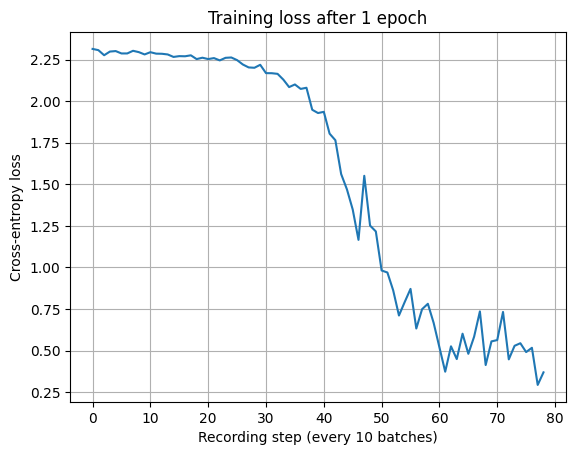

In [ ]:
plt.plot(losses_storage)
plt.xlabel("Recording step (every 10 batches)")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss after 1 epoch")
plt.grid(True)

---
## Step 14 — Evaluation: The Test Function

To measure how well our model **generalises** to unseen data we evaluate it on the validation set.

Key concepts:

| Code | Explanation |
|------|-------------|
| `model.eval()` | Switches model to evaluation mode (disables Dropout, fixes BatchNorm) |
| `torch.no_grad()` | Disables gradient tracking — saves memory and speeds up inference |
| `out.max(1)[1]` | Gets the index of the highest logit per sample — the predicted class |
| `pred.eq(y_batch)` | Boolean tensor: `True` where prediction matches label |

We compute both **loss** and **accuracy** on batches and then average them.  
The function returns all predictions stacked into a single array for later visualisation.

In [ ]:
test_losses = []
test_accs = []
test_size = x_valid.shape[0]
batch_size_test = 1000
predictions = []

def test():
    predictions = []
    model.eval()                  # evaluation mode: no dropout/batchnorm updates
    with torch.no_grad():         # disable gradient computation for efficiency
        for i in range(test_size // batch_size_test):
            start_i = i * batch_size_test
            end_i   = start_i + batch_size_test
            x_batch = x_valid[start_i:end_i]
            y_batch = y_valid[start_i:end_i]

            out  = model(x_batch)           # forward pass (no gradients needed)
            loss = loss_fn(out, y_batch)
            test_losses.append(loss.item())

            pred = out.max(1)[1]            # predicted class = index of highest logit
            acc  = (sum(pred.eq(y_batch)) / len(y_batch))  # fraction correct
            test_accs.append(acc.item())
            predictions.append(pred)

    print("Test set average loss:     {:.4f}".format(np.mean(test_losses)))
    print("Test set average accuracy: {:.4f}".format(np.mean(test_accs)))

    return np.stack(predictions).ravel()  # flatten into a 1-D array of predictions

In [ ]:
# Quick test to verify it runs correctly
preds = test()

Test set average loss:     0.4566
Test set average accuracy: 0.8598


---
## Step 15 — Full Training Loop (3 Epochs)

Now we put it all together. We:
1. Re-initialise the model and optimiser (to start from scratch)
2. Train for **3 epochs**, evaluating on the validation set after each one
3. Use `%%time` to measure the wall-clock time

**What is an epoch?**  
One epoch = one complete pass over the entire training dataset. At `batch_size=64` and 50,000 samples, each epoch consists of 781 gradient updates.

**Expected results after 3 epochs:**  
With SGD at lr=0.01 on CPU, accuracy typically reaches ~97–98% on this dataset.

In [ ]:
%%time
# Full training: re-initialise and train for 3 epochs

num_epochs    = 3
batch_size    = 64
lr            = 0.01
log_interval  = 10

model = CNN()                                   # fresh model (random weights)
opt   = optim.SGD(model.parameters(), lr=lr)   # fresh optimiser

# Reset storage lists
losses_storage = []
test_losses    = []
test_accs      = []

for e in range(1, num_epochs + 1):
    print(f"--- Epoch {e}/{num_epochs} ---")
    train()
    predictions = test()

--- Epoch 1/3 ---
Test set average loss:     0.4822
Test set average accuracy: 0.8416
--- Epoch 2/3 ---
Test set average loss:     0.3799
Test set average accuracy: 0.8783
--- Epoch 3/3 ---
Test set average loss:     0.3186
Test set average accuracy: 0.8994
CPU times: total: 3min 30s
Wall time: 22.6 s


---
## Step 16 — Visualising Training Loss

Instead of plotting loss against the epoch number (which can be misleading with large datasets), we convert batch indices to **number of training samples seen**. This gives a more granular and comparable view of the learning curve.

$$\text{samples seen at step } k = k \times \text{batch\_size}$$

A well-behaved training run should show:
- **High initial loss** (model starts with random weights)
- **Steady decrease** as the model learns
- **Levelling off** as it approaches convergence

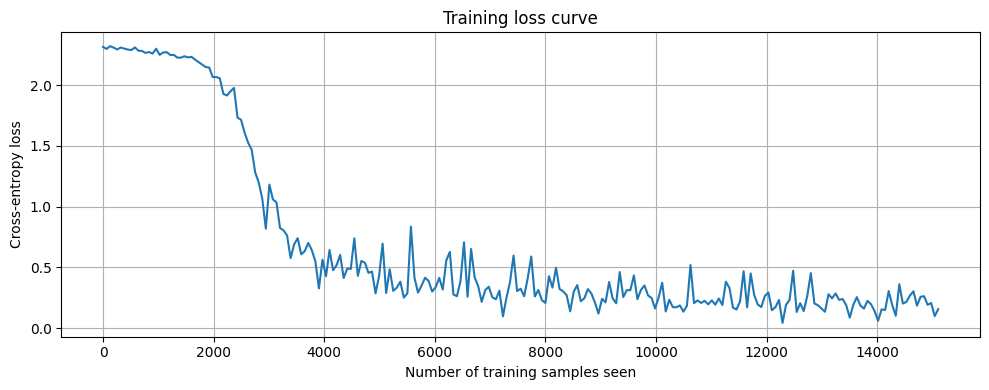

In [ ]:
num_samples_seen = batch_size * np.arange(len(losses_storage))

plt.figure(figsize=(10, 4))
plt.plot(num_samples_seen, losses_storage)
plt.xlabel("Number of training samples seen")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss curve")
plt.grid(True)
plt.tight_layout()

---
## Step 17 — Visualising Predictions

Numbers alone don't tell the whole story. Let's look at **12 randomly selected validation images** and compare the model's prediction to the true label.

- **Correct predictions** will show matching actual and predicted labels.
- **Incorrect predictions** reveal challenging cases — often ambiguous handwriting where even humans might disagree.

Run this cell multiple times to see different random samples.

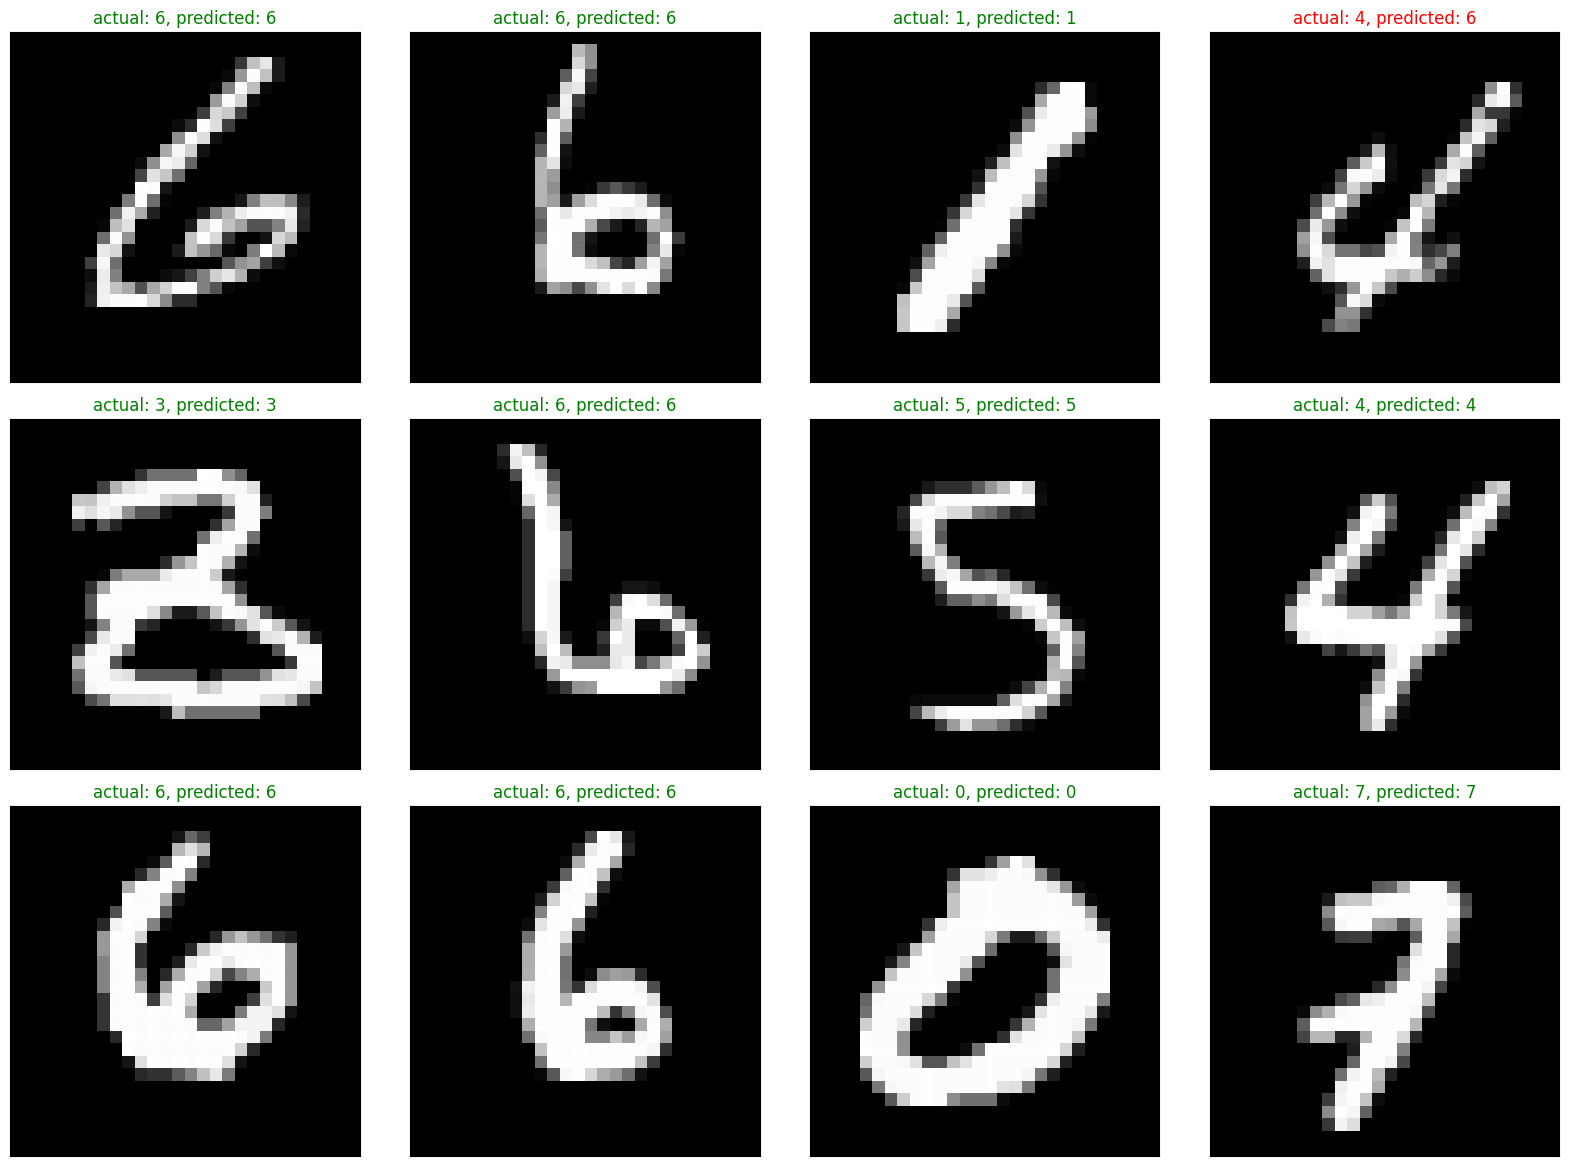

In [ ]:
# Pick 12 random validation samples
examples      = np.random.randint(low=0, high=len(y_valid) - 1, size=12)
y_examples    = y_valid[examples]
pred_examples = predictions[examples]
x_examples    = x_valid[examples]

fig = plt.figure(figsize=(16, 12))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.tight_layout()
    plt.imshow(x_examples[i, 0], cmap="gray")  # channel 0 = greyscale image

    actual    = y_examples[i].item()
    predicted = pred_examples[i].item()
    color     = "green" if actual == predicted else "red"

    plt.title(
        "actual: {}, predicted: {}".format(actual, predicted),
        color=color
    )
    plt.xticks([])
    plt.yticks([])

---
## Step 18 — Accelerating Training with GPU

Training on a CPU is fine for small experiments but can be slow for larger networks or datasets. Modern **GPUs** (Graphics Processing Units) contain thousands of cores designed for the matrix multiplications that dominate neural network computations, often giving **10–100× speedups**.

### How PyTorch handles devices
In PyTorch every tensor and every model parameter lives on a specific **device** (`cpu` or `cuda`). For a computation to work, **all tensors involved must be on the same device**.

| Operation | Code |
|-----------|------|
| Check GPU availability | `torch.cuda.is_available()` |
| Select device | `torch.device('cuda' if torch.cuda.is_available() else 'cpu')` |
| Move model to device | `model.to(device)` |
| Move data tensor to device | `tensor.to(device)` |
| Move result back to CPU | `tensor.cpu()` |

The code is structured so that it **gracefully falls back to CPU** if no GPU is detected — the same function works whether or not a GPU is available.

In [ ]:
# Detect GPU and move model to the appropriate device
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

modelGPU = model.to(device)  # move all model parameters to the device

Using device: cpu


In [ ]:
# Confirm whether CUDA (NVIDIA GPU) is available
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


---
## Step 19 — GPU Training and Testing Functions

The GPU versions of `train` and `test` are nearly identical to the CPU versions with two key differences:

1. Data batches are moved to the device with `.to(device)` **before** being passed to the model.
2. In the test function, predictions are moved back to the CPU with `.cpu()` before converting to NumPy (NumPy cannot work with CUDA tensors).

> **Best practice:** Move data to the GPU in small batches (not the full dataset) to avoid out-of-memory errors on machines with limited GPU RAM.

In [ ]:
def trainGPU():
    model.train()
    for i in range(train_size // batch_size):
        start_i = i * batch_size
        end_i   = start_i + batch_size
        # Move each mini-batch to the GPU just before use
        x_batch = x_train[start_i:end_i].to(device)
        y_batch = y_train[start_i:end_i].to(device)

        pred = modelGPU(x_batch)    # forward pass on GPU
        loss = loss_fn(pred, y_batch)

        loss.backward()
        opt.step()
        opt.zero_grad()

        if i % log_interval == 0:
            losses_storage.append(loss.item())

In [ ]:
test_losses = []
test_accs   = []
test_size   = x_valid.shape[0]
batch_size_test = 1000
predictions = []

def testGPU():
    predictions = []
    model.eval()
    with torch.no_grad():
        for i in range(test_size // batch_size_test):
            start_i = i * batch_size_test
            end_i   = start_i + batch_size_test
            # Move validation batch to GPU
            x_batch = x_valid[start_i:end_i].to(device)
            y_batch = y_valid[start_i:end_i].to(device)

            out  = modelGPU(x_batch)
            loss = loss_fn(out, y_batch)
            test_losses.append(loss.item())

            pred = out.max(1)[1]
            acc  = (sum(pred.eq(y_batch)) / len(y_batch))
            test_accs.append(acc.item())
            # Move predictions back to CPU before converting to NumPy
            predictions.append(pred.detach().clone().cpu().numpy())

    print("Test set average loss:     {:.4f}".format(np.mean(test_losses)))
    print("Test set average accuracy: {:.4f}".format(np.mean(test_accs)))

    return np.stack(predictions).ravel()

---
## Step 20 — Full GPU Training Loop

Run the complete 3-epoch training cycle using the GPU functions. Compare the wall-clock time (`%%time`) against the CPU version — on a modern GPU you should see a significant speedup.

> **Note:** Because we are reusing `model` (which has already been trained), `modelGPU` is an already partially-trained network moved to the GPU. If you want a fully fresh run, re-define `model = CNN()` before this cell.

In [ ]:
%%time
# Full GPU training: 3 epochs

num_epochs   = 3
batch_size   = 64
lr           = 0.01
log_interval = 10

opt = optim.SGD(model.parameters(), lr=lr)

losses_storage = []
test_losses    = []
test_accs      = []

for e in range(1, num_epochs + 1):
    print(f"--- Epoch {e}/{num_epochs} ---")
    trainGPU()
    predictions = testGPU()

---
## Summary and Next Steps

### What we covered

| Concept | Key takeaway |
|---------|-------------|
| **CNN architecture** | Stacking conv → pool → ReLU blocks extracts spatial features hierarchically |
| **Dimension tracking** | Always trace how each operation changes `(N, C, H, W)` |
| **`nn.Module`** | Subclassing it gives you parameter tracking and device management for free |
| **Training loop** | forward → loss → backward → step → zero_grad |
| **Evaluation mode** | `model.eval()` + `torch.no_grad()` for correct, efficient inference |
| **GPU acceleration** | Just `.to(device)` for both model and data tensors |



### Further reading
- [PyTorch `nn.Module` tutorial](https://pytorch.org/tutorials/beginner/nn_tutorial.html)
- [MNIST CNN tutorial (Kaggle)](https://nextjournal.com/gkoehler/pytorch-mnist)
- [Overview of optimisation algorithms](https://ruder.io/optimizing-gradient-descent/index.html)
- [Guide to convolution arithmetic](https://arxiv.org/pdf/1603.07285.pdf)